# Creación de un modelo de clasificación para el conjunto de datos Iris


In this Jupyter notebook, we will be building a classification model for the Iris data set using the random forest algorithm.

## 1. Importar librerías y cargar datos

In [26]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print("Dimensiones:", df.shape)
df.head()


Dimensiones: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [27]:
# Cargar dataset Iris desde scikit-learn
iris = load_iris()
X = iris.data
y = iris.target
columnas = iris.feature_names

df = pd.DataFrame(X, columns=columnas)
df['target'] = y

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2. Exploración rápida
Objetivo: observar la distribución de las características y sus correlaciones iniciales.

In [28]:
# Estadísticas básicas
print(df.describe())

# Conteo de cada clase de flor
print("\nConteo de clases (0=Setosa, 1=Versicolor, 2=Virginica):")
print(df['target'].value_counts())


       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Conteo de clases (0=Setosa, 1=Versicolor, 2=Virginica):
0    50
1    50

## Visualización Básica
Matriz de dispersión: ayuda a ver cómo se separan (o no) las clases respecto a diferentes pares de características.

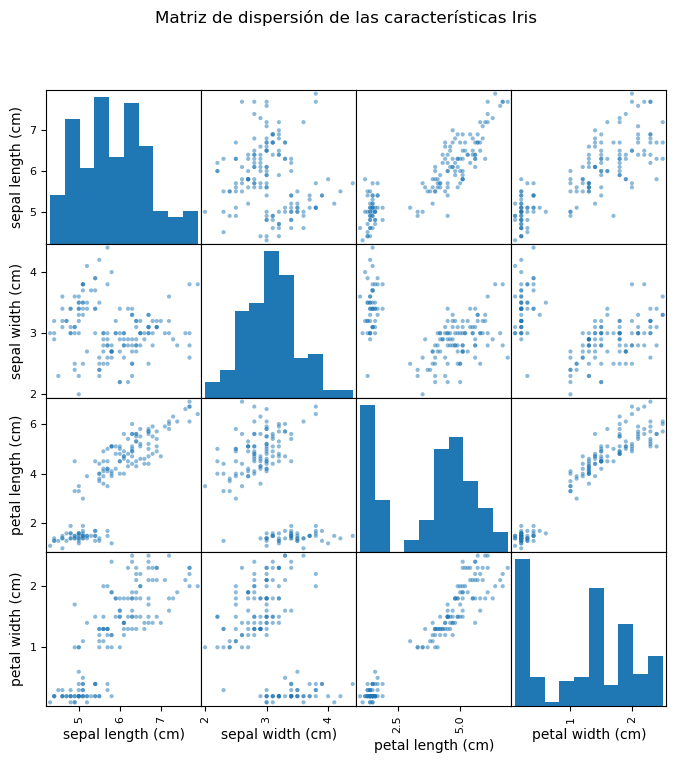

In [29]:
# Usar la función scatter_matrix de pandas (o gráfico manual con matplotlib)
pd.plotting.scatter_matrix(df.iloc[:, :-1], figsize=(8,8))
plt.suptitle("Matriz de dispersión de las características Iris")
plt.show()


## 3. Separar datos en entrenamiento y prueba

Objetivo: Para evaluar correctamente, dividimos en datos de entrenamiento (70-80%) y prueba (20-30%).

In [30]:
# División estratificada para respetar la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

# Escalado (opcional pero recomendable para modelos sensibles a escalas)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Entrenamiento y evaluación de modelos
Se utilizan varios algoritmos para comparar su exactitud y analiar la matriz de confusión


--- RegLog ---
Tiempo de entrenamiento: 0.03688 segundos
Exactitud: 0.93
Reporte:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Matriz de confusión:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


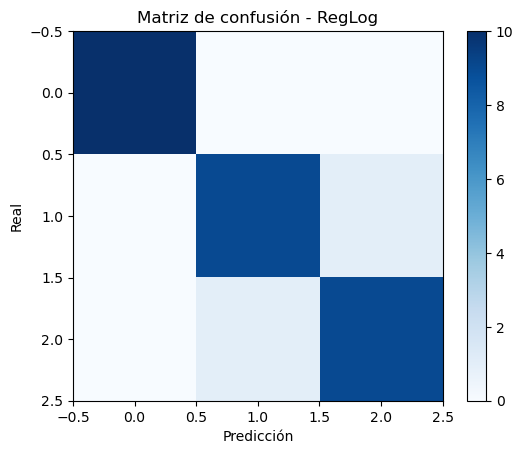


--- Arbol ---
Tiempo de entrenamiento: 0.00399 segundos
Exactitud: 0.93
Reporte:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Matriz de confusión:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


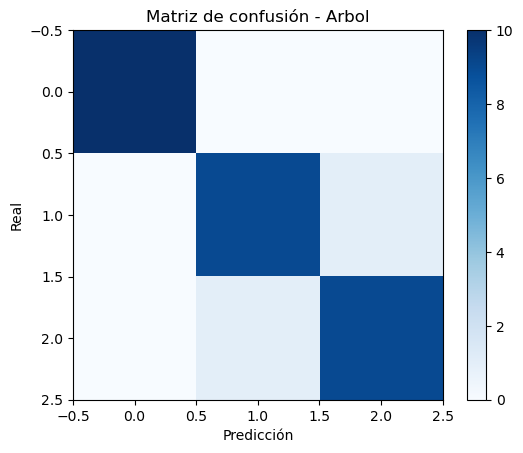


--- SVC ---
Tiempo de entrenamiento: 0.00199 segundos
Exactitud: 0.97
Reporte:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Matriz de confusión:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


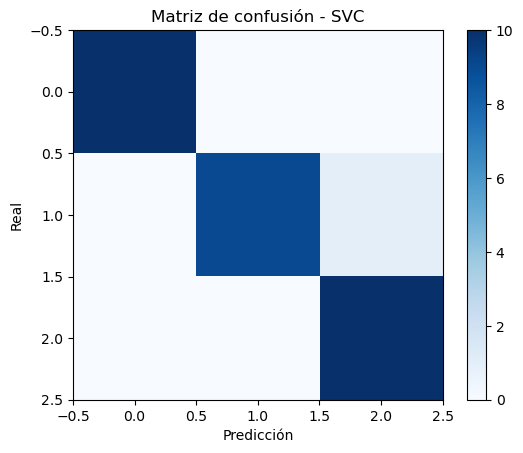


--- RandomForest ---
Tiempo de entrenamiento: 0.14552 segundos
Exactitud: 0.90
Reporte:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Matriz de confusión:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


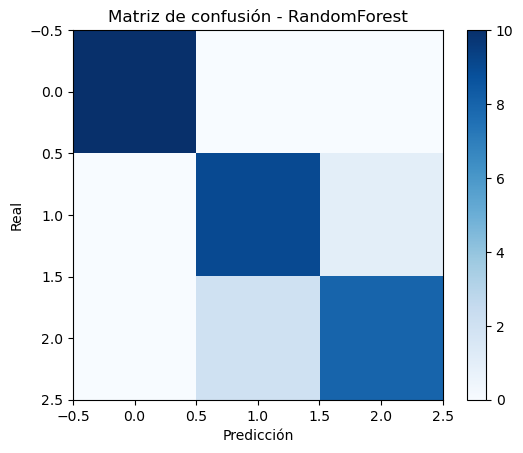

In [39]:
modelos = {
    "RegLog": LogisticRegression(max_iter=200),
    "Arbol": DecisionTreeClassifier(random_state=42),
    "SVC": SVC(),
    "RandomForest": RandomForestClassifier(random_state=42)
}

resultados = {}
tiempos_entrenamiento = {}

for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_scaled, y_train)
    fin = time.time()
    
    tiempo = fin - inicio
    tiempos_entrenamiento[nombre] = tiempo
    
    # Predicción y métricas
    pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    resultados[nombre] = acc
    
    print(f"\n--- {nombre} ---")
    print(f"Tiempo de entrenamiento: {tiempo:.5f} segundos")
    print(f"Exactitud: {acc:.2f}")
    print("Reporte:\n", classification_report(y_test, pred))
    
    cm = confusion_matrix(y_test, pred)
    print("Matriz de confusión:\n", cm)
    
    # Visualizar la matriz de confusión
    plt.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
    plt.title(f"Matriz de confusión - {nombre}")
    plt.colorbar()
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()



## 5. Comparación final de exactitud


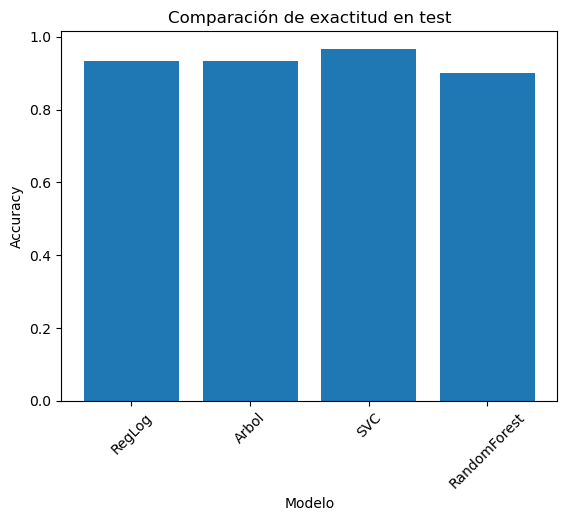

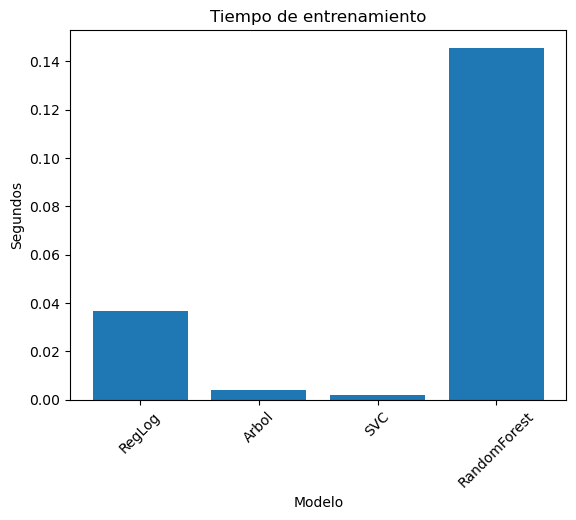

In [40]:
# Gráfico de exactitud
plt.bar(resultados.keys(), resultados.values())
plt.title("Comparación de exactitud en test")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# Gráfico de tiempos
plt.bar(tiempos_entrenamiento.keys(), tiempos_entrenamiento.values())
plt.title("Tiempo de entrenamiento")
plt.xlabel("Modelo")
plt.ylabel("Segundos")
plt.xticks(rotation=45)
plt.show()



## 6. Función para predecir con los modelos entrenados
Definimos una función que recibe un diccionario de modelos entrenados y un conjunto de datos (ya escalados). Retorna o imprime las predicciones de cada modelo.

In [41]:
def predecir_modelos(modelos_entrenados, X_nuevo):
    """
    Recibe:
      - modelos_entrenados (dict): diccionario {nombre_modelo: objeto_modelo_entrenado}
      - X_nuevo (array o DataFrame): muestras a clasificar (ya escaladas, si corresponde)
    Devuelve:
      - Un dict con las predicciones de cada modelo
    """
    predicciones = {}
    for nombre, modelo in modelos_entrenados.items():
        y_pred = modelo.predict(X_nuevo)
        predicciones[nombre] = y_pred
    return predicciones

# Ejemplo de uso:
# Supongamos que queremos predecir con las primeras 3 instancias de X_test escaladas
X_nuevo = X_test_scaled[:3]
preds = predecir_modelos(modelos, X_nuevo)
for nombre_modelo, valor_pred in preds.items():
    print(f"{nombre_modelo}: {valor_pred}")


RegLog: [0 2 1]
Arbol: [0 2 1]
SVC: [0 2 1]
RandomForest: [0 2 1]


## 7. Seleccionar el mejor modelo
Suponiendo que ya tenemos el diccionario resultados (con las accuracies) y el diccionario modelos (con los modelos entrenados), seleccionaremos el modelo con mayor exactitud:

In [42]:
# Encontrar el nombre del modelo con mejor accuracy
mejor_modelo_nombre = max(resultados, key=resultados.get)
mejor_modelo = modelos[mejor_modelo_nombre]

print("El mejor modelo es:", mejor_modelo_nombre)
print("Exactitud en test:", resultados[mejor_modelo_nombre])


El mejor modelo es: SVC
Exactitud en test: 0.9666666666666667


Creamos una función que reciba las cuatro medidas típicas de la flor (longitud y ancho de sépalo, longitud y ancho de pétalo), aplique el mismo escalador que se usó en el entrenamiento y retorne la clase predicha.

In [43]:
def predecir_flor_iris(long_sepalo, ancho_sepalo, long_petalo, ancho_petalo, model, scaler):
    """
    long_sepalo: longitud del sépalo (float)
    ancho_sepalo: ancho del sépalo (float)
    long_petalo: longitud del pétalo (float)
    ancho_petalo: ancho del pétalo (float)
    
    model: modelo de clasificación entrenado
    scaler: objeto para escalar los datos (StandardScaler usado en entrenamiento)
    
    Retorna: la clase predicha (0=Setosa, 1=Versicolor, 2=Virginica)
    """
    
    # Formar un array (1,4) con la muestra a predecir
    X_nuevo = np.array([[long_sepalo, ancho_sepalo, long_petalo, ancho_petalo]])
    
    # Escalar con el mismo scaler usado en entrenamiento
    X_nuevo_scaled = scaler.transform(X_nuevo)
    
    # Realizar la predicción
    pred_clase = model.predict(X_nuevo_scaled)
    
    return pred_clase[0]  # 0, 1 o 2


In [44]:
# Ejemplo de flor hipotética
prediccion = predecir_flor_iris(
    long_sepalo=5.1, 
    ancho_sepalo=3.5, 
    long_petalo=1.4, 
    ancho_petalo=0.2, 
    model=mejor_modelo, 
    scaler=scaler
)

print("Clase predicha (0=Setosa, 1=Versicolor, 2=Virginica):", prediccion)


Clase predicha (0=Setosa, 1=Versicolor, 2=Virginica): 0


### P1. ¿Por qué crees que el escalado de características influye en algunos modelos más que en otros?
### P2. ¿Qué ventajas/desventajas encuentras entre los modelos determinísticos (como árboles de decisión) y los modelos basados en distancia (KNN, SVC)?
